# Simulation

This section demonstrates how to simulate compartmental models in PyGOM.
By the end of this introduction you will be able to:
 
- Define initial conditions for a model.
- Run deterministic simulations using ODE solvers.
- Run stochastic simulations using continuous-time Markov chain (CTMC) methods.
- Interpret simulation outputs: state trajectories and event counts.
- Use both fixed and randomly sampled parameters.

For an overview of the differences between ODE and CTMC formulations, see Section X.

## Preliminary set-up

### Model definition

We begin our demonstration by defining an SIR model in PyGOM.

In [1]:
from pygom import SimulateOde, Transition, TransitionType

stateList = ['S', 'I', 'R']
paramList = ['beta', 'gamma', 'N']
transitionList = [
    Transition(origin='S', destination='I', equation='beta*S*I/N', transition_type=TransitionType.T),
    Transition(origin='I', destination='R', equation='gamma*I', transition_type=TransitionType.T)]

model = SimulateOde(stateList, paramList, transition=transitionList)

### Parameters

We start by parameterising the model with fixed values.
Note that here, unlike beta and gamma, N is declared globally.
This is because this parameter is reused when defining the initial conditions.

In [2]:
N = 1e4
fixed_param_set = [('beta', 0.35), ('gamma', 0.25), ('N', N)]

model.parameters = fixed_param_set

### Initial conditions

In order to simulate how the system evolves in time, the initial state and time must be specified.
Rather than being passed directly to the solver, these are supplied to the PyGOM model object.
In this way, PyGOM will first perform some validation checks before it calls the solver itself.
Currently, stochastic simulation only supports discrete state populations and so the initial state values must be of integer data type.

In [3]:
import numpy as np

i0 = 10                                             # Initial number infected
x0 = np.array([N-i0, i0, 0], dtype=np.int64)        # Set initial conditions to integer
t0 = 0.0                                            # Initial time point

model.initial_values = (x0, t0) 

### Specifying output times

The user must specify either a set of output times or a maximum simulation time.
Note that, in the former case, this sets the time points at which the solution is returned and does not determine the internal time steps taken by the integrator.
In the latter case, the system is simulated from the initial time (specified by the initial conditions above) up until the maximum time, with output time steps being determined by the specific method.

In [4]:
tmax = 100.0                          # maximum time over which to run solver
dt = 1.0                              # step size
t_eval = np.arange(t0, tmax, dt)      # array of times at which solution output will be evaluated

## Quick Start

The simplest deterministic simulation in PyGOM is:

In [5]:
solution = model.solve_deterministic(t_eval)

The simplest stochastic simulation is:

In [6]:
solution = model.solve_stochastic(
    t=t_eval,
    method="fixed_tau",
    tau=0.1,
    iteration=10
)

In both cases, the solver returns a list of {class}`Output` objects, with one item per simulation realisation.
The deterministic example above therefore returns a list of length 1, whereas the stochastic example returns a list of length 10.

The simulation results are stored in the result attribute. This contains:

- t: output time points
- y: state trajectories
- event_counts: the number of occurrences of each transition between consecutive output times

The remainder of this chapter explains how deterministic and stochastic solvers work, how to configure them, and how to interpret their outputs.

## Deterministic evolution

### Overview

Before we run a deterministic simulation, it is worth briefly outlining what PyGOM does when the deterministic solver is called.
As has been outlined previously in the documentation, once a compartmental model has been defined, PyGOM can build the corresponding ODE representation in both symbolic and python function form.
The ODEs for the state rates of change are calculated via the {func}`model.ode` function.
For example, when evaluated at the initial conditions:

In [7]:
model.ode(x0, t0)

array([-3.4965,  0.9965,  2.5   ])

The ODE function, {func}`model.ode`, is, in principle, ready to be passed to {func}`scipy.integrate.solve_ivp`.
However, PyGOM takes an extra step prior to solving: the set of state ODEs are augmented with equations for variables which track the cumulative number of times each event type occurs (the states and initial conditions are automatically augmented too).

```{dropdown} How PyGOM computes deterministic event counts
For example, if we instead had an SEIR model, as well as the following state equations:

$
\begin{align}
\frac{\mathrm{d}S}{\mathrm{d}t} &=  - \frac{\beta S I}{N} \\
\frac{\mathrm{d}E}{\mathrm{d}t} &=  \frac{\beta S I}{N} - \alpha E \\
\frac{\mathrm{d}I}{\mathrm{d}t} &=  \alpha E - \gamma I\\
\frac{\mathrm{d}R}{\mathrm{d}t} &=  \gamma I
\end{align}
$

we track the cumulative infection, latent progression and recovery events ($T_1$, $T_2$ and $T_3$ respectively):

$
\begin{align}
\frac{\mathrm{d}T_1}{\mathrm{d}t} &=  \frac{\beta S I}{N} \\
\frac{\mathrm{d}T_2}{\mathrm{d}t} &=  \alpha E \\
\frac{\mathrm{d}T_3}{\mathrm{d}t} &=  \gamma I
\end{align}
$

Once integration is complete, the augmented state array is prepared for output by being split back into the state and event components.
The cumulative events are also differenced, giving the number of times each event occurs per timestep.
Automatically calculating these extra variables is useful in instances where quantities such as incidence, rather than prevalence, are required.
Although it would be possible to obtain these values via manipulations of the output states, in this case:

$
\begin{align}
T_1 &=  S(0) - S(t) \\
T_2 &=  S(0) - S(t) + E(0) - E(t) \\
T_3 &=  R(t) - R(0)
\end{align}
$

this approach becomes complicated with increasing model complexity and is also prone to rounding errors, for example, when S(0) and S(t) are large but close.
```

### Solution

In summary, when we call {func}`solve_deterministic`, this augmented set of ODEs is built and then integrated using {func}`scipy.integrate.solve_ivp` under the hood.

In [8]:
solution = model.solve_deterministic(t_eval)

Whilst the underlying solver is obscured by this wrapping, any parameters which may be passed to {func}`scipy.integrate.solve_ivp` can be included as key word arguments in {func}`solve_deterministic`, so no functionality of the integrator is lost.
Furthermore, because PyGOM stores a symbolic representation of the model, it may easily calculate the Jacobian and so for methods for which it is required (e.g. LSODA, Radau, BDF), the user need only specify the method and PyGOM will pass the Jacobian.
Indeed, `LSODA` is the default integrator used by PyGOM.

As an example of declaring `scipy` arguments via PyGOM:

In [9]:
solution = model.solve_deterministic(t_eval, method="RK45", rtol=1e-5)

For the SIR model used throughout this chapter:

- y has three columns corresponding to the states S, I, and R
- event_counts has two columns corresponding to infection and recovery events
- event_counts has one fewer row than t, since events are recorded between consecutive output times

Note that state and event identifiers correspond to the order in which they were defined in the model.
In our SIR example here:

States:

- 0: S
- 1: I
- 2: R

Events:

- 0: S → I (infection)
- 1: I → R (recovery)

The results are unpacked and dimensions can be inspected as follows:

In [10]:
t = solution[0].result.t
y = solution[0].result.y
event_counts = solution[0].result.event_counts

results = {
    'Timepoints': t,
    'State': y,
    'Events': event_counts
}

import pandas as pd

df = pd.DataFrame({
        "Shape": {k: v.shape for k, v in results.items()}
})

print(df)

               Shape
Timepoints    (100,)
State       (100, 3)
Events       (99, 2)


PyGOM's plotting functionality is a work in progress, so for now let's visualise using matplotlib.
Note that we plot event counts as bars to remind ourselves that they represent counts in a given time interval.

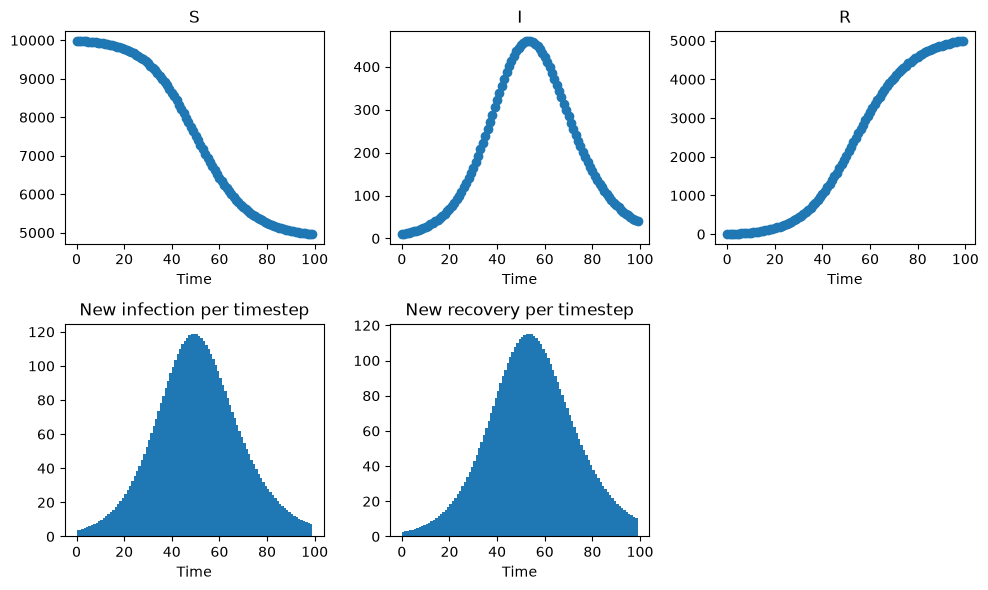

In [11]:
import matplotlib.pyplot as plt

transition_names = ["infection", "recovery"]

fig, ax = plt.subplots(2, 3, figsize=(10, 6))

for i in range(3):
    ax[0][i].plot(t, y[:,i], marker = 'o')
    ax[0][i].set_xlabel('Time')
    ax[0][i].set_title(stateList[i])

widths = np.diff(t)

for i in range(2):
    ax[1][i].bar(t[:-1], event_counts[:, i], width=widths, align='edge')
    ax[1][i].set_xlabel('Time')
    ax[1][i].set_title(f"New {transition_names[i]} per timestep")

ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

```{warning}
### Note on output intervals

This is more a general comment on compartmental models than a specific feature of PyGOM, but worth bearing in mind.
If we change the output time interval, the underlying state solution will be the same and just the points at which it is evaluated will differ.
The event counts, however, do depend on timesteps - for example weekly case counts are higher than daily.

Therefore, when comparing incidence-like quantities, it is a good idea to use a consistent output grid.

We demonstrate below for timesteps of 5 and 11 days.
```

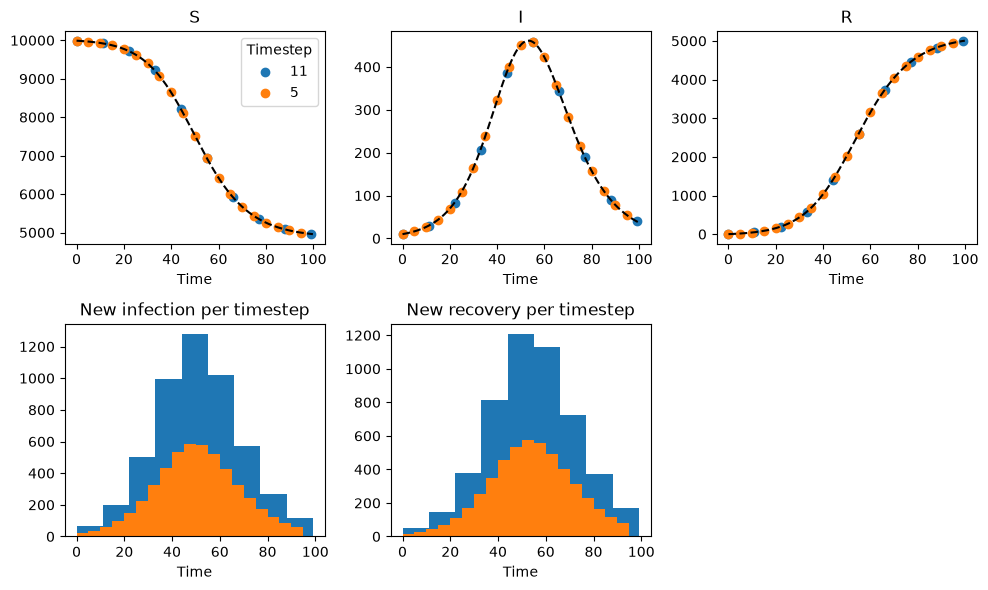

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6))

# Solve and plot at high resolution:
t_eval_fine = np.arange(t0, tmax, 0.1)
solution = model.solve_deterministic(t_eval_fine)

for i in range(3):
    ax[0][i].plot(solution[0].result.t, solution[0].result.y[:,i], color="black", linestyle="--")

# Solve at 2 different timesteps:
timesteps = [11, 5]
colours=["C0", "C1"]

for k, timestep in enumerate(timesteps):
    t_eval_coarse = np.arange(t0, tmax, timestep)

    solution = model.solve_deterministic(t_eval_coarse)
    t = solution[0].result.t
    y = solution[0].result.y
    event_counts = solution[0].result.event_counts

    for i in range(3):
        ax[0][i].scatter(t, y[:,i], color=colours[k], label=timestep)
        ax[0][i].set_xlabel('Time')
        ax[0][i].set_title(stateList[i])

    widths = np.diff(t)

    for i in range(2):
        ax[1][i].bar(t[:-1], event_counts[:, i], width=widths, align='edge', color=colours[k], label=timestep)
        ax[1][i].set_xlabel('Time')
        ax[1][i].set_title(f"New {transition_names[i]} per timestep")

    ax[1][2].axis('off')

ax[0][0].legend(title="Timestep")

plt.tight_layout()
plt.show()

As mentioned, instead of output evaluation times, we can specify a maximum simulation time.
In this case, the output timesteps will be chosen by {func}`scipy.integrate.solve_ivp`

In [13]:
solution = model.solve_deterministic(tmax)

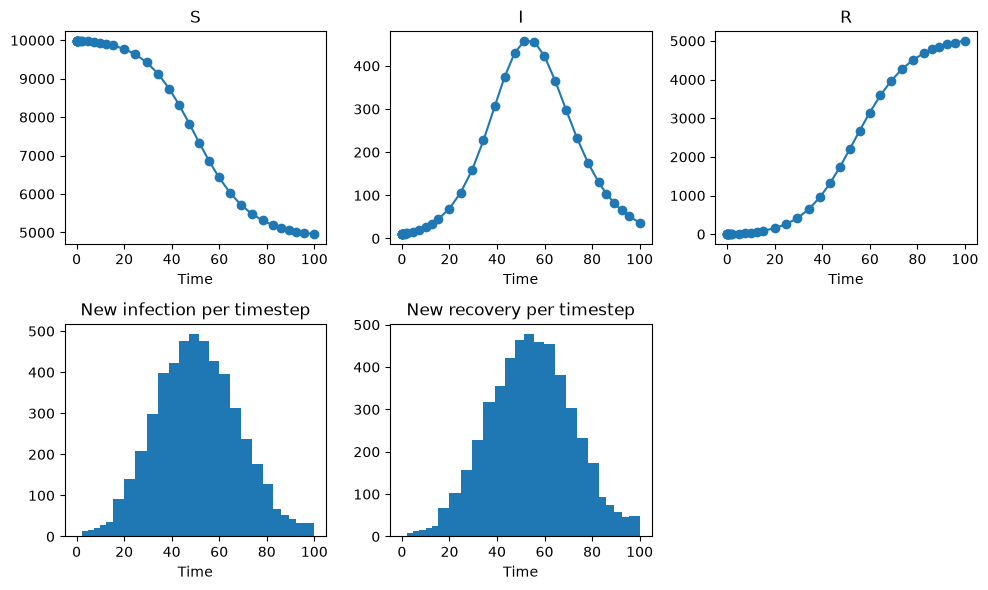

In [14]:
t = solution[0].result.t
y = solution[0].result.y
event_counts = solution[0].result.event_counts

fig, ax = plt.subplots(2, 3, figsize=(10, 6))

for i in range(3):
    ax[0][i].plot(t, y[:,i],  marker = 'o')
    ax[0][i].set_xlabel('Time')
    ax[0][i].set_title(stateList[i])

widths = np.diff(t)

for i in range(2):
    ax[1][i].bar(t[:-1], event_counts[:, i], width=widths, align='edge')
    ax[1][i].set_xlabel('Time')
    ax[1][i].set_title(f"New {transition_names[i]} per timestep")

ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

Again, we note how varying time steps can create illusions in count data if not accounted for by the viewer.
In the above plot, increases in timestep size around 20 and 100 days, for example, can give the impression of a sudden increase in recoveries.

## Stochastic evolution

### Overview

<!-- The approximation that numbers of individuals in each state may be treated as a continuum break down when their sizes are small.
In this regime, transitions between states do not represent continuous flows but are instead stochastic events that occur at rates governed by the current state of the system.
A CTMC assumption that waiting times for these events to occur are exponentially distributed (memoryless), allows for quicker evaluation of the dynamics. -->
<!-- Two common algorithms have been implemented for use during simulation; the reaction method {cite}`Gillespie1977` and the $\tau$-Leap method
{cite}`Cao2006`.
The two change interactively depending on the size of the states. -->


An introduction to compartmental models formulated as continuous-time Markov chains (CTMCs) is provided in Section X.
PyGOM supports stochastic simulation of CTMC models using two classes of algorithms: tau-leaping methods and exact (Gillespie) methods.
Briefly, tau-leaping methods provide a stochastic analogue of deterministic numerical integration: the system evolves in discrete time steps, during which multiple transition events may occur.
In contrast, Gillespie algorithms are event-driven and simulate each transition individually as it occurs.
This accuracy comes at an increased computational cost, particularly for large populations or systems with high event rates.
Guidance on selecting an appropriate simulation method is provided at the end of this section.

### Tau-Leaping

PyGOM implements tau-leaping algorithms using either fixed or adaptive time-step selection, with the adaptive approach following the method of Cao et al. (2006).

```{note}
The primary advantage of adaptive time stepping is that it provides a largely hands-off simulation experience.
Rather than requiring the user to manually select an appropriate step size, the algorithm automatically adjusts the time step according to the current state of the system.
This can improve computational efficiency while maintaining the desired level of accuracy, reducing the need for manual tuning.

However, the adaptive algorithm of Cao et al. was originally developed for stochastic chemical kinetics, and its suitability for epidemiological models is less clear.
In particular, an ideal adaptive scheme for epidemic systems should accurately reproduce quantities such as extinction probabilities, final-size distributions, and the magnitude and timescale of endemic fluctuations.

We are currently investigating alternative adaptive strategies better suited to epidemiological applications.
Until these are available, we recommend using a fixed time step.

If the characteristic timescales of the system are known, the time step should be chosen to be substantially smaller than the fastest timescale.
A good practical approach is to progressively reduce the step size until averages of the quantities of interest no longer change appreciably.
```

The stochastic solver, {func}`solve_stochastic`, is called in much the same way as the deterministic solver, except that

- A stochastic simulation method must be specified.
- Method-specific configuration parameters may be required.
- Multiple simulation realisations can be generated by setting `iteration`.

```{tip}
Set `seed` to obtain reproducible stochastic simulations.
```

In [15]:
solution = model.solve_stochastic(
    t=t_eval,
    method="fixed_tau",
    tau=0.1,
    iteration=10,
    seed=1)

There is also the option ``proceed_if_rates_zero``, which, when set to the default value ``False``, will cease simulation if all of the event rates are zero.
This will typically prevent wasting unnecessary computation on a static system.
If ``proceed_if_rates_zero=True``, the simulation continues until the maximum requested time point is reached.
This can be useful if output at specific timepoints is required or in scenarios where rates may only temporarily be zero due to time dependent effects - for example if seasonal forcing is modelled using a binary square wave.

If ``proceed_if_rates_zero=True``, the simulation continues until the maximum requested time point is reached, even when all event rates are zero. This can be useful when output is required at specific time points, or in scenarios where rates may subsequently become non-zero due to time-dependent effects, such as seasonal forcing or the introduction or removal of non-pharmaceutical interventions (NPIs).



We now visualise the simulated epidemic trajectories.
Since multiple simulation realisations are being visualised simultaneously, the count variables are shown as lines rather than bars.

```{note}
When mapping the simulated trajectories from the internal integration times to the requested output times, interpolation may be required.
As a result, the reported values are not guaranteed to be integers, even though the underlying model states represent counts.
To minimise interpolation artefacts, it can be helpful to choose output times that align with the simulation time step.
For example, if using a tau-leap step size of 0.1 days, output times could be specified at 1-day intervals.

A future release of PyGOM aims to ensure that the solver always evaluates the system at the requested output times, eliminating instances of non integer counts introduced by interpolation.
```

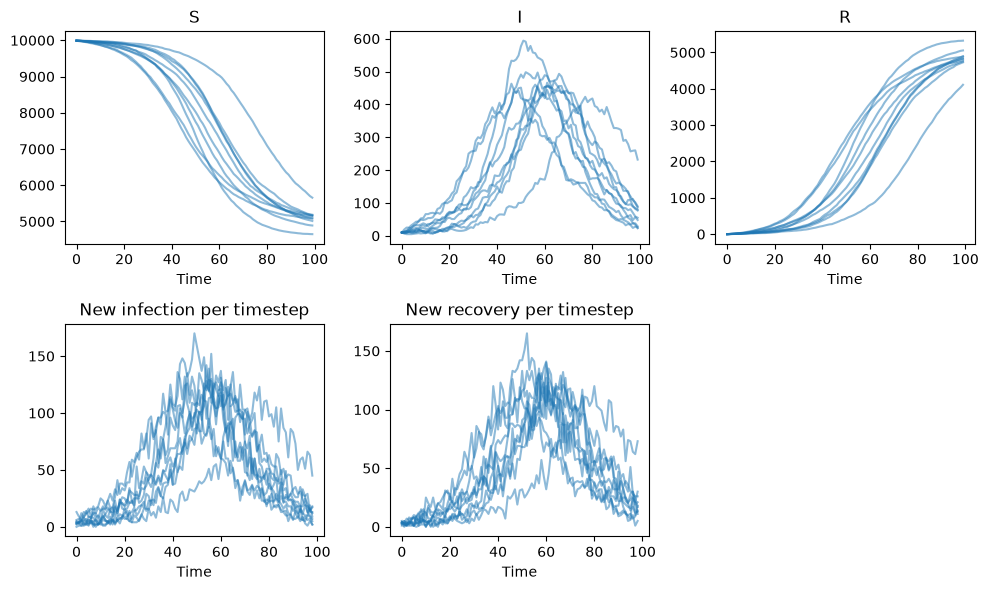

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6))

for k in range(10):
    t = solution[k].result.t
    y = solution[k].result.y
    event_counts = solution[k].result.event_counts

    for i in range(3):
        ax[0][i].plot(t, y[:,i], color = "C0", alpha=0.5)
        ax[0][i].set_xlabel('Time')
        ax[0][i].set_title(stateList[i])

    for i in range(2):
        ax[1][i].plot(t[:-1], event_counts[:,i], color = "C0", alpha=0.5)
        ax[1][i].set_xlabel('Time')
        ax[1][i].set_title(f"New {transition_names[i]} per timestep")

    ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

### Exact (Gillespie)

PyGOM provides two exact stochastic simulation algorithms: the **First Reaction Method** and the **Direct Method**.
In most applications, the Direct Method is more computationally efficient and is therefore the recommended choice.
Both algorithms generate exact sample paths of the underlying continuous-time Markov chain by simulating each transition event individually.

```{note}
Because events are simulated exactly and the system state is updated only through discrete transitions, the reported compartment counts are always integer-valued.
Unlike tau-leaping methods, no interpolation is involved in preparing the simulation outputs.
```

First, we solve with target output times specified and plot the results in the same way as previously.
For exact methods, the simulation always terminates if all event rates are zero.

In [17]:
solution = model.solve_stochastic(
    t=t_eval,
    method="direct",
    iteration=10,
    seed=1)

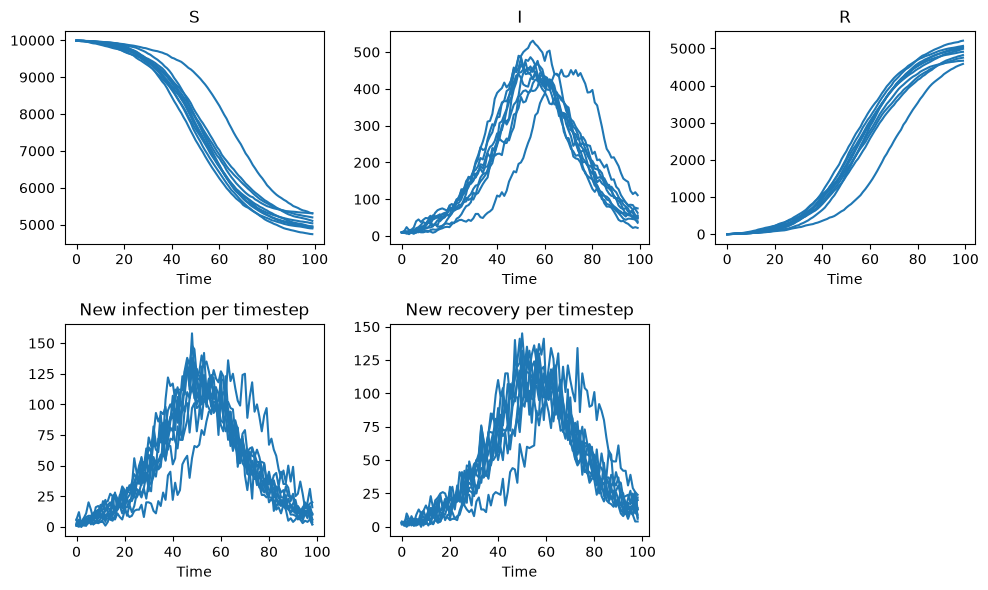

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6))

for k in range(10):
    t = solution[k].result.t
    y = solution[k].result.y
    event_counts = solution[k].result.event_counts

    for i in range(3):
        ax[0][i].plot(t, y[:,i], color="C0")
        ax[0][i].set_xlabel('Time')
        ax[0][i].set_title(stateList[i])

    # Compute widths
    t_min = t[:-1]

    for i in range(2):
        ax[1][i].plot(t_min, event_counts[:,i], color="C0")
        ax[1][i].set_xlabel('Time')
        ax[1][i].set_title(f"New {transition_names[i]} per timestep")

    ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

The binning of the reactions into desired timesteps obscures the individual reactions.
If we wish to see the individual events, then we instead specify the maximum simulation time.

In [19]:
solution = model.solve_stochastic(
    t=tmax,
    method="direct",
    iteration=10,
    seed=1)

For exact stochastic methods, the output format, {class}`EventOutput`, differs slightly when a maximum simulation time is specified.
In this case the `result` attribute contains:

- the times of each event occurance (plus the initial time point)
- the state populations after each event (plus the initial state condition)
- the id of the event which occured

As before, we inspect the dimensions of the returned arrays.
Note that `event_id` is one row shorter than the time array, since no events occur at the initial time point.

In [20]:
results = {
    'Event time': solution[0].result.t,
    'State': solution[0].result.y,
    'Event id': solution[0].result.event_id
}

df = pd.DataFrame({
        "Shape": {k: v.shape for k, v in results.items()}
})

print(df)

                 Shape
Event time    (10070,)
State       (10070, 3)
Event id      (10069,)


We plot the state trajectories, but the event counts are not easily represented graphically in their raw form.
Instead, we use a table to illustrate the first few reactions.

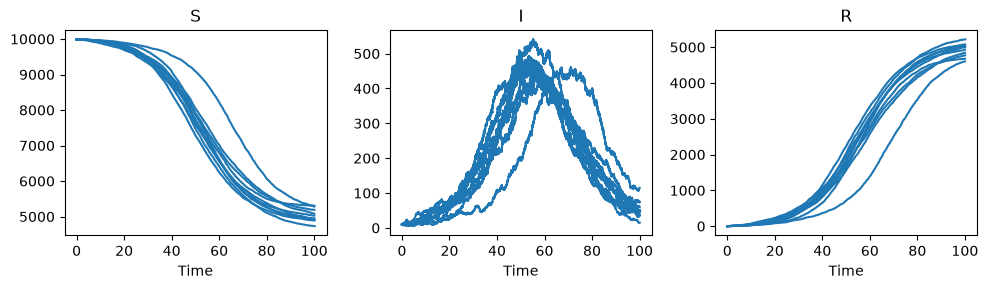

   Event Time  Event ID Event type
0    0.428332         1   recovery
1    0.630661         0  infection
2    0.784895         1   recovery
3    1.169442         0  infection
4    1.381293         0  infection
5    1.448905         1   recovery
6    1.547641         1   recovery
7    1.638290         0  infection
8    1.699507         0  infection


In [21]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

for k in range(10):
    t = solution[k].result.t
    y = solution[k].result.y

    for i in range(3):
        ax[i].plot(t, y[:,i], color="C0")
        ax[i].set_xlabel('Time')
        ax[i].set_title(stateList[i])
plt.tight_layout()
plt.show()

t = solution[0].result.t
event_id = solution[0].result.event_id

df = pd.DataFrame({
    "Event Time": t[1:10],
    "Event ID": event_id[:9],
    "Event type": [transition_names[i] for i in event_id[:9]]
})

print(df)

### Choosing a stochastic method

It is up to the user to decide on the most appropriate CTMC method, but this will most likely be tau leap.
Some basic guidlines:

Use exact simulation when:
- populations are small
- event timing is important
- maximum accuracy is required

Use tau-leap methods when:
- populations are large
- many repeated simulations are needed
- computational speed is important

## Random parameters

Finally, we demonstrate how to approach scenarios where the parameters are drawn randomly from some distributions.
We define random param set and pass them to our PyGOM model as follows:

In [22]:
gamma_mn = 0.25
beta_mn = 0.35

gamma_var = (gamma_mn / 10)**2  # Set the standard deviation to be 0.1x the mean value
gamma_shape = (gamma_mn**2) / gamma_var
gamma_rate = gamma_mn / gamma_var

beta_var = (beta_mn / 10)**2  # Set the standard deviation to be 0.1x the mean value
beta_shape = (beta_mn**2) / beta_var
beta_rate = beta_mn / beta_var

from pygom.utilR import rgamma
random_param_set = dict()  # container for random param set
random_param_set['gamma'] = (rgamma, {'shape': gamma_shape, 'rate': gamma_rate})
random_param_set['beta'] = (rgamma, {'shape': beta_shape, 'rate': beta_rate})
random_param_set['N'] = N

model.parameters = random_param_set

In this example we solve deterministically, though we can equally solve stochastically.
The `iteration` argument refers to the number of simulations performed, each one with an independently drawn parameter set.

In [23]:
solution = model.solve_deterministic(
    t=t_eval,
    iteration=10,
    seed=1)

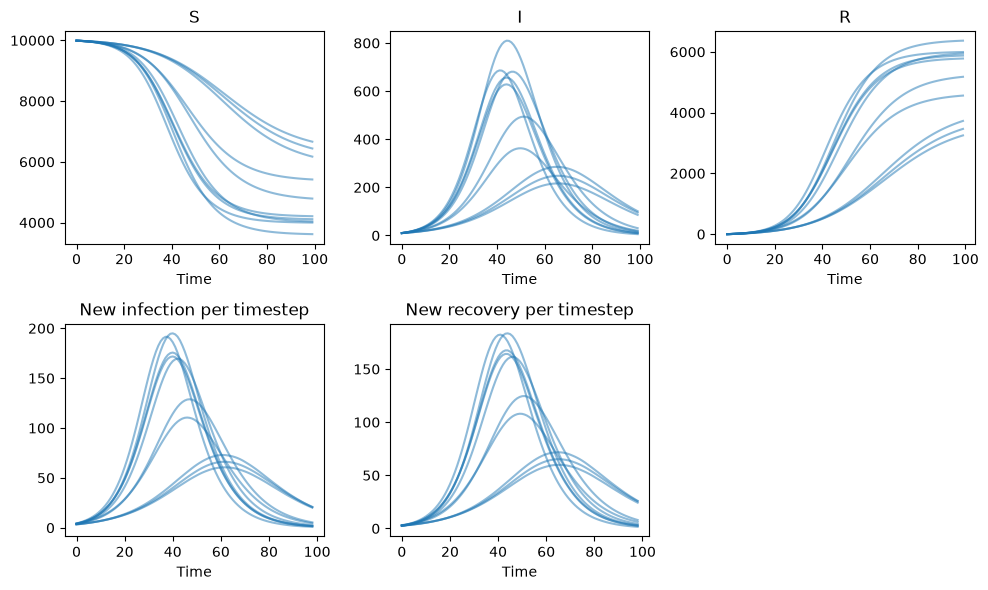

In [24]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6))

for k in range(10):
    t = solution[k].result.t
    y = solution[k].result.y
    event_counts = solution[k].result.event_counts

    for i in range(3):
        ax[0][i].plot(t, y[:,i], color = "C0", alpha=0.5)
        ax[0][i].set_xlabel('Time')
        ax[0][i].set_title(stateList[i])

    for i in range(2):
        ax[1][i].plot(t[:-1], event_counts[:,i], color = "C0", alpha=0.5)
        ax[1][i].set_xlabel('Time')
        ax[1][i].set_title(f"New {transition_names[i]} per timestep")

    ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

## Summary

With deterministic vs stochastic simulation and fixed vs random parameters, we have explored the four total model configurations.
We plot these results side by side for the infected compartment to provide an illustration of their key qualitative differences.

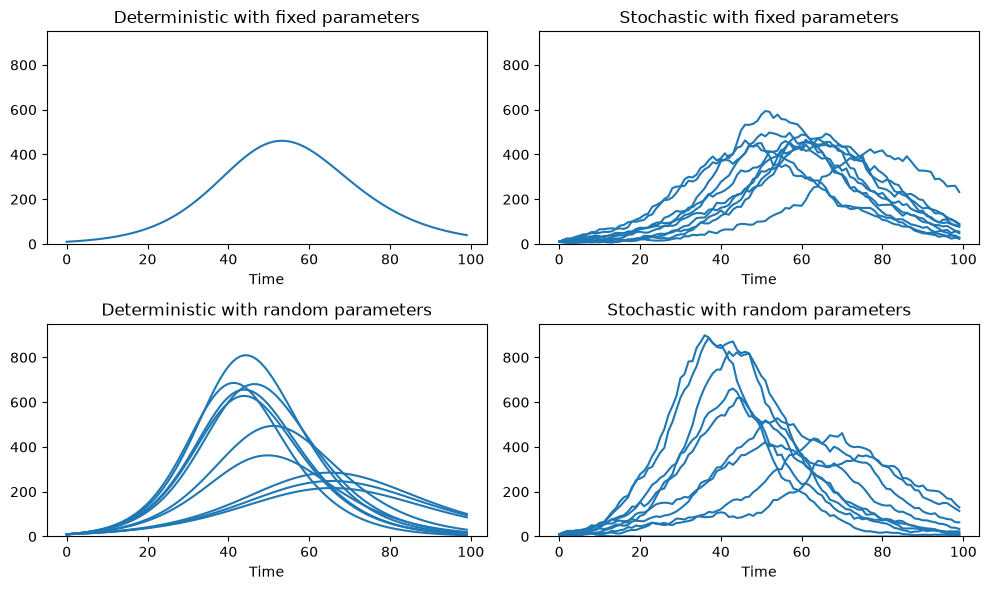

In [25]:
solution_collection = {}

parameter_types = {
    "fixed": fixed_param_set,
    "random": random_param_set,
}

solvers = {
    "Deterministic": lambda iter: model.solve_deterministic(t_eval, iteration=iter, seed=1),
    "Stochastic": lambda iter: model.solve_stochastic(t_eval, iteration=iter, method="fixed_tau", tau=0.1, seed=1),
}

for param_name, params in parameter_types.items():
    model.parameters = params

    for sim_name, solve in solvers.items():
        niter = 10
        if (param_name=="fixed") & (sim_name=="Deterministic"):
            niter = 1
        solution_collection[f"{sim_name} with {param_name} parameters"] = solve(niter).copy()

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

ax_flat = axes.flatten()

for ax, (name, solution) in zip(ax_flat, solution_collection.items()):
    nsim = len(solution)

    for sim in range(nsim):
        ax.plot(solution[sim].result.t, solution[sim].result.y[:, 1], color="C0")
        ax.set_title(name)

    ax.set_xlabel("Time")
    ax.set_ylim(0, 950)

plt.tight_layout()
plt.show()

<!-- ## Repeatable Simulation

One of the possible uses of compartmental models is to generate
forecasts. Although most of the time the requirement would be to have
(at least point-wise) convergence in the limit, reproducibility is also
important. For both types of interpretation explained above, we have
given the package the capability to repeat the simulations by setting a
seed. When the assumption is that the parameters follows some sort of
distribution, we can set the seed which governs the global state of
the random number generator.




x0 = [2362206.0, 3.0, 0.0]

odeS = SimulateOde(stateList, paramList, transition=transitionList)

d = {'beta': st.gamma(a=100.0, scale=1.0/200.0), 'gamma':st.gamma(a=100.0, scale=1.0/300.0), 'N': x0[0]}

odeS.parameters = d

odeS.initial_values = (x0, t[0])

Ymean, Yall = odeS.solve_determ(t[1::], 10, full_output=True)



np.random.seed(1)

Ymean1, Yall1 = odeS.solve_determ(t[1::], 10, full_output=True)

np.random.seed(1)

Ymean2, Yall2 = odeS.solve_determ(t[1::], 10, full_output=True)

sim_diff = [np.linalg.norm(Yall[i] - yi) for i, yi in enumerate(Yall1)]

sim_diff12 = [np.linalg.norm(Yall2[i] - yi) for i, yi in enumerate(Yall1)]

print("Different in the simulations and the mean: (%s, %s) " %(np.sum(sim_diff), np.sum(np.abs(Ymean1 - Ymean))))

print("Different in the simulations and the mean using same seed: (%s, %s) " % (np.sum(sim_diff12), np.sum(np.abs(Ymean2 - Ymean1))))


In the alternative interpretation, setting the global seed is
insufficient. Unlike simulation based on the parameters, where we can
pre-generate all the parameter values and send them off to individual
processes in the parallel backend, this is prohibitive here. In a
nutshell, the seed does not propagate when using a parallel backend
because each *integration* requires an unknown number of random samples.
Therefore, we have an additional flag **parallel** in the function
signature. By ensuring that the computation runs in serial, we can make
use of the global seed and generate identical runs.


x0 = [2362206.0, 3.0, 0.0]

odeS = SimulateOde(stateList, paramList, transition=transitionList)

odeS.parameters = [0.5, 1.0/3.0, x0[0]]

odeS.initial_values = (x0, t[0])

simX, simT = odeS.simulate_jump(t[1:10], 10, parallel=False, full_output=True)

np.random.seed(1)

simX1, simT1 = odeS.simulate_jump(t[1:10], 10, parallel=False, full_output=True)

np.random.seed(1)

simX2, simT2 = odeS.simulate_jump(t[1:10], 10, parallel=False, full_output=True)

sim_diff = [np.linalg.norm(simX[i] - x1) for i, x1 in enumerate(simX1)]

sim_diff12 = [np.linalg.norm(simX2[i] - x1) for i, x1 in enumerate(simX1)]

print("Difference in simulation: %s" %np.sum(np.abs(sim_diff)))

print("Difference in simulation using same seed: %s" %np.sum(np.abs(sim_diff12))) -->